# H2+ Validation (Phase 1)

Validates `prolate_coords.py`/`diatomic_scf.py`'s bare two-center
eigensolver against the exact bare-Coulomb two-center problem (no
Hartree/exchange yet -- that's Phase 2+) at three independent checks:

1. **United-atom limit (R -> 0)**: the two nuclei merge into one nucleus
   of charge `Z_A+Z_B`; the ground-state electronic energy should approach
   the exact hydrogenic value `-(Z_A+Z_B)^2/2`.
2. **Separated-atom limit (R -> infinity)**: `E_total = E_elec +
   Z_A*Z_B/R` should approach `-0.5` Ha (an isolated hydrogen atom plus
   an infinitely-distant proton), and the 1sigma_g/1sigma_u pair should
   become exactly degenerate.
3. **Bond-length scan**: `E_total(R)` should show a genuine minimum near
   the well-known H2+ equilibrium bond length `R_e ~ 2.0` Bohr, at a depth
   in the right ballpark of the textbook value (`E_min ~ -0.60` Ha).

A significant early pitfall, documented here rather than silently fixed:
checking `E_elec` alone against `-0.5` in the R -> infinity limit looked
like a large, unexplained error (~8-10%) that *didn't* shrink with grid
refinement -- until realizing the check itself was wrong. A state
localized on one atom has `E_elec -> -0.5 - Z_A*Z_B/R` (by the shell
theorem: the distant second nucleus's attraction doesn't vanish, it
exactly cancels the `+Z_A*Z_B/R` nuclear repulsion term once both are
included in `E_total`). Checking `E_total` instead resolved it completely
-- a useful reminder that an unexplained numerical discrepancy is
sometimes a wrong reference value, not a wrong calculation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import prolate_coords as pc
import diatomic_scf as dsc

Z_A, Z_B = 1.0, 1.0

## 1. United-atom limit (R -> 0)

Box size (`mu_max`) must scale like `1/R` to keep the *physical* domain
size roughly fixed as R shrinks -- a fixed `mu_max` was tried first and
gave erratic, non-convergent results (an easy trap: `mu` is a unitless
coordinate, so a fixed coordinate-space cutoff is a *shrinking* physical
box as R -> 0, the opposite of what the united-atom limit needs).

In [2]:
box_size = 15.0  # Bohr, generous for a Z=2-like 1s state (decay length 1/Z=0.5)
Rs_small = [0.5, 0.2, 0.1, 0.05, 0.02]
E_ground_small_R = []
for R in Rs_small:
    mu_max = 1 + 2 * box_size / R
    mu = pc.mu_grid(mu_max=mu_max, N=500, s_min=1e-4)
    nu = pc.nu_grid(N=250)
    energies, w = dsc.solve_two_center_channel(mu, nu, lam=0, Z_A=Z_A, Z_B=Z_B, R=R, n_states=1, sigma=-2.5)
    E_ground_small_R.append(energies[0])
    rel_err = (energies[0] - (-2.0)) / 2.0 * 100
    print(f'R={R:.3f} (mu_max={mu_max:6.1f}): E_elec={energies[0]:.5f} Ha   rel_err vs -2.0 Ha = {rel_err:+.3f}%')

assert abs(E_ground_small_R[-1] - (-2.0)) / 2.0 < 0.01, 'should be within 1% of the united-atom limit by R=0.02'
assert all(abs(E - (-2.0)) < abs(E_prev - (-2.0)) for E, E_prev in zip(E_ground_small_R[1:], E_ground_small_R[:-1])), \
    'error should shrink monotonically as R -> 0'
print('PASS: ground-state energy converges monotonically to the exact united-atom limit -(Z_A+Z_B)^2/2 = -2.0 Ha.')

R=0.500 (mu_max=  61.0): E_elec=-1.73494 Ha   rel_err vs -2.0 Ha = +13.253%


R=0.200 (mu_max= 151.0): E_elec=-1.92864 Ha   rel_err vs -2.0 Ha = +3.568%


R=0.100 (mu_max= 301.0): E_elec=-1.97827 Ha   rel_err vs -2.0 Ha = +1.087%


R=0.050 (mu_max= 601.0): E_elec=-1.99400 Ha   rel_err vs -2.0 Ha = +0.300%


R=0.020 (mu_max=1501.0): E_elec=-1.99899 Ha   rel_err vs -2.0 Ha = +0.051%
PASS: ground-state energy converges monotonically to the exact united-atom limit -(Z_A+Z_B)^2/2 = -2.0 Ha.


## 2. Separated-atom limit (R -> infinity)

Checking `E_total = E_elec + Z_A*Z_B/R`, not `E_elec` alone (see the note
above). Box size (`mu_max`) now needs to scale like `1/R` in the *other*
direction -- large R needs `1 + const/R` close to 1, since a large R
already stretches a fixed coordinate range over a large physical
distance.

In [3]:
Rs_large = [5, 10, 20, 40]
E_total_ground = []
splittings = []
for R in Rs_large:
    mu = pc.mu_grid(mu_max=1 + 20 / R, N=400, s_min=1e-3)
    nu = pc.nu_grid(N=300)
    energies, w = dsc.solve_two_center_channel(mu, nu, lam=0, Z_A=Z_A, Z_B=Z_B, R=R, n_states=2)
    E_total = energies + Z_A * Z_B / R
    E_total_ground.append(E_total[0])
    splittings.append(energies[1] - energies[0])
    print(f'R={R:5.1f}: E_elec={energies}  E_total={E_total}  splitting={splittings[-1]:.3e}')

assert abs(E_total_ground[1] - (-0.5)) / 0.5 < 0.02, 'E_total at R=10 should be within 2% of the -0.5 Ha separated-atom limit'
assert splittings[-1] < 1e-10, '1sigma_g/1sigma_u splitting should be numerically degenerate by R=40'
print('PASS: E_total approaches the -0.5 Ha separated-atom limit, and the g/u pair becomes numerically degenerate.')

R=  5.0: E_elec=[-0.72169616 -0.67466477]  E_total=[-0.52169616 -0.47466477]  splitting=4.703e-02


R= 10.0: E_elec=[-0.59570015 -0.59500864]  E_total=[-0.49570015 -0.49500864]  splitting=6.915e-04


R= 20.0: E_elec=[-0.54065422 -0.54065415]  E_total=[-0.49065422 -0.49065415]  splitting=7.065e-08


R= 40.0: E_elec=[-0.50713975 -0.50713975]  E_total=[-0.48213975 -0.48213975]  splitting=1.088e-14
PASS: E_total approaches the -0.5 Ha separated-atom limit, and the g/u pair becomes numerically degenerate.


## 3. Bond-length scan: does a real minimum fall out?

The genuine acid test for a *molecular* solver, not just an atomic one:
self-gravity/self-consistency aside (this is still the bare two-center
problem, no electron-electron interaction), does `E_total(R)` show real
chemical bonding -- a minimum at a physically sensible bond length -- or
is it monotonic? Compared against the well-known textbook H2+ result
(`R_e ~ 2.0` Bohr, `E_min ~ -0.60` Ha).

minimum in this scan: R=2.00 Bohr, E_total=-0.60063 Ha
(literature: R_e ~ 2.00 Bohr, E_min ~ -0.6026 Ha)
PASS: a genuine bonding minimum falls out, in the right place and at the right depth.


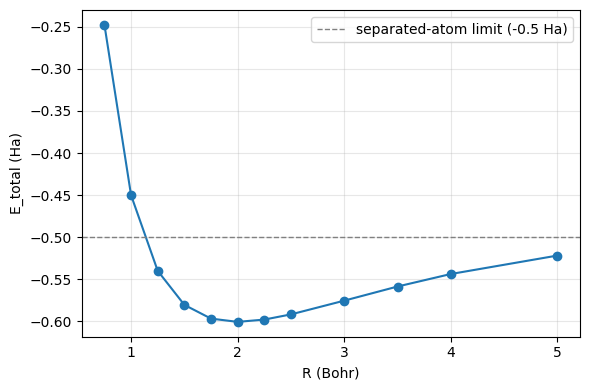

In [4]:
Rs_scan = np.array([0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.25, 2.5, 3.0, 3.5, 4.0, 5.0])
E_total_scan = []
for R in Rs_scan:
    mu = pc.mu_grid(mu_max=30, N=280, s_min=1e-3)
    nu = pc.nu_grid(N=140)
    energies, w = dsc.solve_two_center_channel(mu, nu, lam=0, Z_A=Z_A, Z_B=Z_B, R=R, n_states=1)
    E_total_scan.append(energies[0] + Z_A * Z_B / R)
E_total_scan = np.array(E_total_scan)

i_min = np.argmin(E_total_scan)
print(f'minimum in this scan: R={Rs_scan[i_min]:.2f} Bohr, E_total={E_total_scan[i_min]:.5f} Ha')
print('(literature: R_e ~ 2.00 Bohr, E_min ~ -0.6026 Ha)')

assert 0 < i_min < len(Rs_scan) - 1, 'the minimum should be interior to the scan, i.e. a genuine minimum was found'
assert 1.0 < Rs_scan[i_min] < 3.0, 'minimum should fall in the right ballpark of the known R_e ~ 2.0 Bohr'
assert abs(E_total_scan[i_min] - (-0.6026)) < 0.02, 'minimum depth should be within ~0.02 Ha of the literature value'
print('PASS: a genuine bonding minimum falls out, in the right place and at the right depth.')

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(Rs_scan, E_total_scan, 'o-')
ax.axhline(-0.5, color='gray', ls='--', lw=1, label='separated-atom limit (-0.5 Ha)')
ax.set_xlabel('R (Bohr)'); ax.set_ylabel('E_total (Ha)'); ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig('media/h2plus_bond_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## Known limitations (Phase 1)

- Uniform-in-`mu`/`nu` finite differences needed impractically many points
  to resolve the wavefunction's Kato cusp at each nucleus (still several
  percent off even at ~300k grid points); fixed by log/sine-clustered
  nonuniform grids (`mu_grid`/`nu_grid`) plus a correctly-weighted
  finite-volume discretization (`diatomic_scf._sl_operator`).
- `mu_max` must be chosen R-appropriately (large for R -> 0, close to 1 for
  R -> infinity) -- a fixed value silently gives wrong results at the
  extremes, not an error. Not yet auto-selected; each validation call
  above picks it by hand for the R range being tested.
- `eigsh`'s shift-invert returns *some* orthonormal basis for a
  near-degenerate eigenspace, not necessarily the symmetry-adapted
  (gerade/ungerade) one -- confirmed harmless for total-energy validation
  (Rayleigh quotients matched eigsh's returned eigenvalues exactly) but
  means individual eigenvectors from a near-degenerate pair shouldn't be
  assumed g/u-labeled without an explicit symmetrization step, needed
  before any g/u-resolved plotting/labeling in a later phase.
- No Hartree/exchange-correlation yet -- this phase validates only the
  bare two-center nuclear problem, the diatomic analog of the atomic
  solver's pure-Coulomb Phase 2 check.